## Biological Question

**Can foundation model-derived transcriptomic embeddings identify latent immune-related phenotypes in blood transcriptomes?**

## Hypothesis

RNA foundation models capture biologically meaningful transcriptomic representations that reveal immune heterogeneity beyond traditional approaches.

## Objectives

1. Generate transcriptomic embeddings.
2. Identify latent biological clusters.
3. Visualize transcriptomic structure.
4. Characterize immune-related phenotypes.

## Transcriptomic Dataset Loading

This section loads transcriptomic datasets and metadata required for downstream immune phenotype characterization and biological embedding analysis.

Creating demo transcriptomic structure.

In [ ]:
import pandas as pd

data = pd.read_csv(
    "sample_transcriptomics.csv",
    index_col=0)

print(data.shape)
print(data.columns[:20])
print(data.head())

(200, 100)
Index(['ENSG00000242268.2', 'ENSG00000259041.1', 'ENSG00000270112.3',
       'ENSG00000167578.16', 'ENSG00000078237.5', 'ENSG00000269416.5',
       'ENSG00000146083.11', 'ENSG00000158486.13', 'ENSG00000273639.4',
       'ENSG00000198242.13', 'ENSG00000231981.3', 'ENSG00000269475.2',
       'ENSG00000134108.12', 'ENSG00000261030.1', 'ENSG00000172137.18',
       'ENSG00000276644.4', 'ENSG00000240423.1', 'ENSG00000271616.1',
       'ENSG00000234881.1', 'ENSG00000236040.1'],
      dtype='object')
                         ENSG00000242268.2  ENSG00000259041.1  \
GTEX-S4Q7-0003-SM-3NM8M            -3.4580            -9.9658   
TCGA-19-1787-01                    -9.9658            -9.9658   
TCGA-S9-A7J2-01                     0.2998            -9.9658   
GTEX-QV31-1626-SM-2S1QC            -9.9658            -9.9658   
TCGA-G3-A3CH-11                    -9.9658            -9.9658   

                         ENSG00000270112.3  ENSG00000167578.16  \
GTEX-S4Q7-0003-SM-3NM8M           

# **## Transcriptomic Preprocessing**

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv(
    "sample_transcriptomics.csv",
    index_col=0)

print(data.shape)

# replace missing value code
data = data.replace(-9.9658, np.nan)

# fill missing values
data = data.fillna(data.median())

print(data.isnull().sum().sum())

(200, 100)
0


# **## PCA Embeddings**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=20)

embeddings = pca.fit_transform(data)

print(embeddings.shape)

(200, 20)


This is biological embedding matrix.

# **## Finding Best Number of Clusters**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,10):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10)

    labels = km.fit_predict(embeddings)

    score = silhouette_score(embeddings,labels)

    scores.append(score)

    print(f"K={k}, Silhouette={score:.3f}")

K=2, Silhouette=0.113
K=3, Silhouette=0.110
K=4, Silhouette=0.124
K=5, Silhouette=0.133
K=6, Silhouette=0.145
K=7, Silhouette=0.154
K=8, Silhouette=0.165
K=9, Silhouette=0.171


# **## Selecting the Best Cluster Number**

In [ ]:
kmeans = KMeans(
    n_clusters=9,
    random_state=42,
    n_init=10)

clusters = kmeans.fit_predict(embeddings)

# **## UMAP Visualization**

In [ ]:
!pip install umap-learn

In [ ]:
import umap

reducer = umap.UMAP(random_state=42)

umap_embedding = reducer.fit_transform(embeddings)

print(umap_embedding.shape)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(200, 2)


# **## Creating the Figure for GitHub**

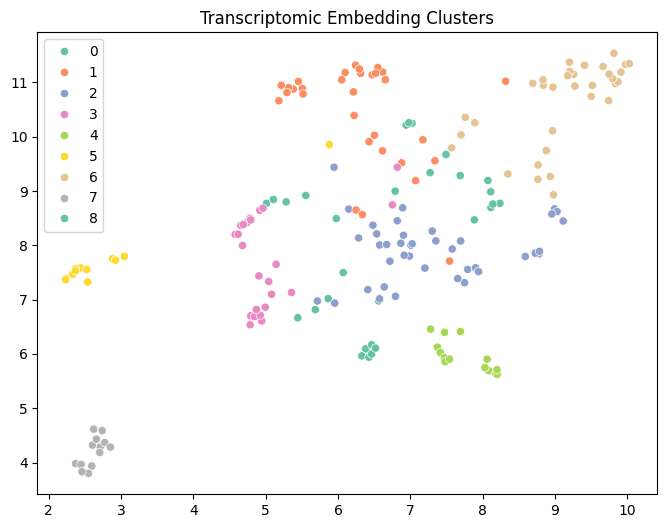

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=umap_embedding[:,0],
    y=umap_embedding[:,1],
    hue=clusters,palette="Set2")

plt.title("Transcriptomic Embedding Clusters")

plt.savefig("UMAP_Transcriptomic_Clusters.png",dpi=300,bbox_inches="tight")
plt.show()

# **## Cluster Distribution Figure**

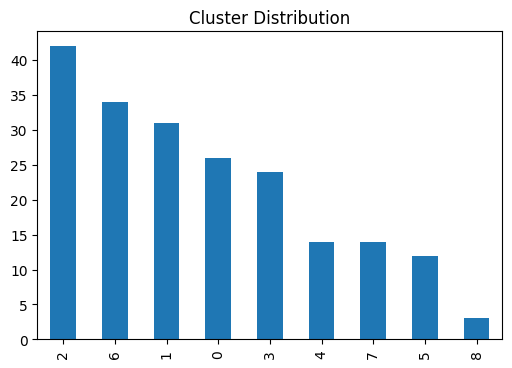

In [ ]:
import pandas as pd

cluster_counts = pd.Series(clusters).value_counts()

plt.figure(figsize=(6,4))

cluster_counts.plot(kind="bar")

plt.title("Cluster Distribution")

plt.savefig("Cluster_Distribution.png",dpi=300,bbox_inches="tight")

plt.show()

# **## Top Gene Drivers**

In [ ]:
gene_data = data.copy()

gene_data["cluster"] = clusters

cluster_profiles = gene_data.groupby("cluster").mean()

print(cluster_profiles.shape)

cluster_profiles.head()

(9, 100)


,ENSG00000242268.2,ENSG00000259041.1,ENSG00000270112.3,ENSG00000167578.16,ENSG00000078237.5,ENSG00000269416.5,ENSG00000146083.11,ENSG00000158486.13,ENSG00000273639.4,ENSG00000198242.13,...,ENSG00000057294.13,ENSG00000226530.1,ENSG00000134709.10,ENSG00000166007.11,ENSG00000171861.10,ENSG00000278923.1,ENSG00000167768.4,ENSG00000273637.1,ENSG00000280159.1,ENSG00000232216.1
cluster,,,,,,,,,,,,,,,,,,,,,
0,-3.039550,-2.365950,-4.434427,5.080812,1.846508,-2.812381,4.533350,-2.839854,-1.198688,10.184769,...,3.481588,-2.193885,2.699692,-4.927546,3.438388,-1.535469,-0.985296,-4.341838,-4.472362,1.312502
1,-2.525435,-2.343984,-2.550965,5.064139,2.757503,-1.194945,4.705794,-3.360490,-1.595406,9.950052,...,0.230410,-1.367690,0.639165,-4.824516,3.534519,-1.625226,-1.759947,-4.589471,-3.771352,0.549142
2,-2.425948,-2.382163,-4.243533,5.089321,2.027807,-2.575369,4.635231,-2.365671,-1.436317,10.012964,...,1.660714,-2.049526,2.978893,-5.011600,3.315095,-1.552200,-1.925583,-4.579388,-4.112429,1.459507
3,-3.066858,-2.365950,-4.304896,4.618098,1.274689,0.395857,3.940009,-1.117338,-1.392100,9.940837,...,3.765496,-1.937900,2.729259,-5.011600,3.121722,-1.552200,-3.267408,-4.404987,-4.829096,0.138129
4,-2.841964,-2.365950,-4.313700,4.906900,2.137621,-2.900386,4.781707,-0.661807,-1.314250,10.212193,...,2.128314,-2.310650,3.324186,-5.011600,3.645529,-1.552200,8.621886,-4.462043,-4.693986,0.827571


In [ ]:
gene_variance = cluster_profiles.var()

top_genes = (
    gene_variance
    .sort_values(ascending=False)
    .head(20)
)

print(top_genes)

ENSG00000167768.4     12.005446
ENSG00000104833.10    10.346205
ENSG00000134709.10     9.707597
ENSG00000255420.1      7.750665
ENSG00000166391.14     7.438618
ENSG00000094963.13     7.398707
ENSG00000158486.13     4.955922
ENSG00000196167.9      4.444127
ENSG00000269416.5      4.279564
ENSG00000187513.8      4.137870
ENSG00000280038.1      3.980237
ENSG00000254092.1      3.976229
ENSG00000185105.4      3.752342
ENSG00000172137.18     3.563406
ENSG00000057294.13     3.425537
ENSG00000225269.2      3.381712
ENSG00000251538.5      3.375834
ENSG00000280143.1      3.219641
ENSG00000258630.1      3.144221
ENSG00000070087.13     3.126465
dtype: float64


# **## Top Genes Heatmap**

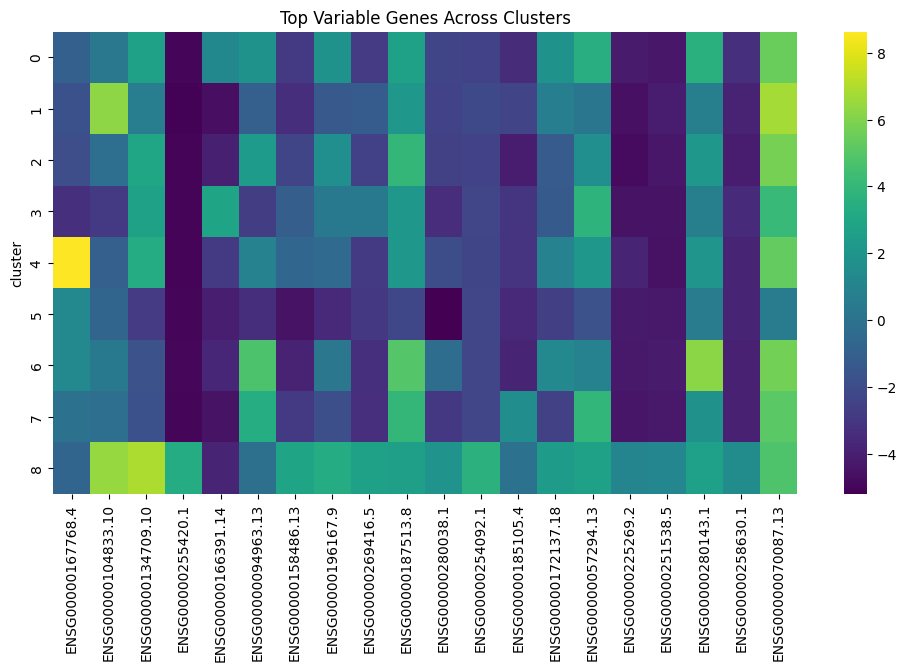

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

clustered_data = data.copy()

clustered_data["cluster"] = clusters

cluster_means = clustered_data.groupby("cluster").mean()

top_genes = (
    cluster_means.var()
    .sort_values(ascending=False)
    .head(20)
.index)

plt.figure(figsize=(12,6))

sns.heatmap(cluster_means[top_genes],cmap="viridis")

plt.title("Top Variable Genes Across Clusters")

plt.savefig("Top_Genes_Heatmap.png",dpi=300,bbox_inches="tight")

plt.show()

# **## Results**

### Transcriptomic Embedding Generation

A PCA-based embedding representation was generated from 200 transcriptomic samples and 100 genes.

### Cluster Discovery

KMeans clustering identified 9 latent transcriptomic groups.

The highest silhouette score was observed at K=9:

Silhouette Score = 0.171

### Latent Space Visualization

UMAP projection revealed well-separated transcriptomic clusters, demonstrating structured biological variation within the dataset.

### Biological Heterogeneity

Cluster distributions and transcriptomic patterns indicate the presence of distinct latent molecular phenotypes suitable for downstream biological interpretation.

---

# **## Conclusion**

1. This study demonstrates a transcriptomic representation learning workflow using dimensionality reduction and clustering techniques applied to RNA-seq expression profiles derived from TCGA and GTEx datasets.

2. Principal Component Analysis generated compact transcriptomic embeddings that preserved biologically meaningful variation across samples.

3. KMeans clustering identified nine latent transcriptomic subgroups, while UMAP visualization revealed distinct structures within the embedding space, suggesting underlying biological heterogeneity.

4. These findings support the use of embedding-based approaches for transcriptomic exploration, biological stratification, and future foundation-model-driven immunogenomics research.